## STEP 1: IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor

## STEP 2: LOAD DATASET

In [2]:
df = pd.read_csv("Tesla.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (1692, 7)
        Date       Open   High        Low      Close    Volume  Adj Close
0  6/29/2010  19.000000  25.00  17.540001  23.889999  18766300  23.889999
1  6/30/2010  25.790001  30.42  23.299999  23.830000  17187100  23.830000
2   7/1/2010  25.000000  25.92  20.270000  21.959999   8218800  21.959999
3   7/2/2010  23.000000  23.10  18.709999  19.200001   5139800  19.200001
4   7/6/2010  20.000000  20.00  15.830000  16.110001   6866900  16.110001


## STEP 3: DATA CLEANING

In [3]:
df['Date'] = pd.to_datetime(df['Date'])

df.sort_values('Date', inplace=True)

print("\nMissing Values:\n", df.isnull().sum())

df.dropna(inplace=True)


Missing Values:
 Date         0
Open         0
High         0
Low          0
Close        0
Volume       0
Adj Close    0
dtype: int64


## STEP 4: EXPLORATORY DATA ANALYSIS

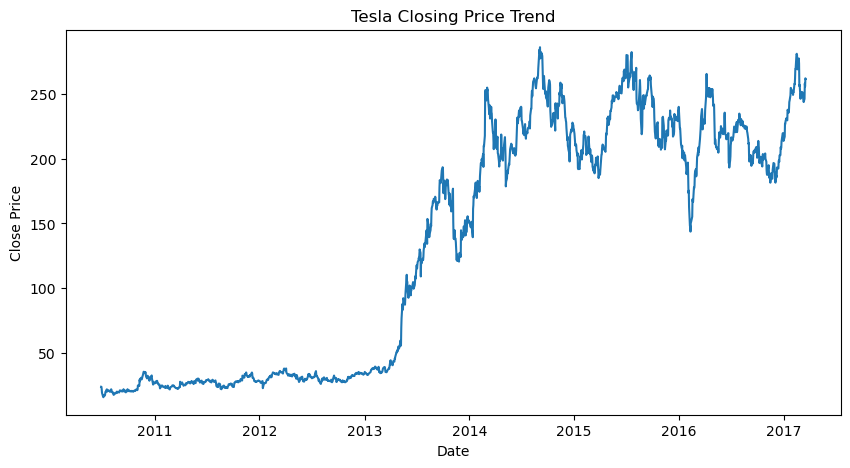

In [4]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'])
plt.title("Tesla Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

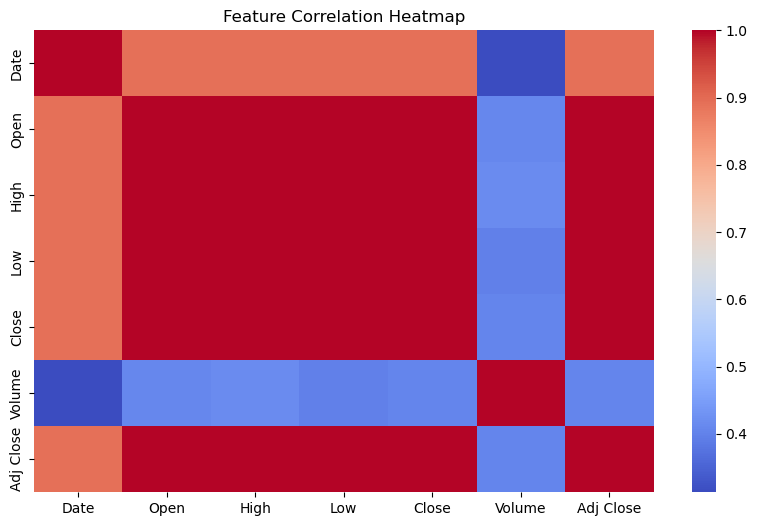

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## STEP 5: FEATURE ENGINEERING

In [6]:
df['Price_Change'] = df['Close'] - df['Open']

df['Daily_Return'] = df['Close'].pct_change()

df['MA5'] = df['Close'].rolling(5).mean()

df['MA10'] = df['Close'].rolling(10).mean()

df['MA20'] = df['Close'].rolling(20).mean()

df['Volatility'] = df['Close'].rolling(5).std()

df['Lag_1'] = df['Close'].shift(1)

df['Lag_2'] = df['Close'].shift(2)

df['Lag_3'] = df['Close'].shift(3)

df.dropna(inplace=True)


## STEP 6: FEATURE SELECTION

In [7]:
features = [
    'Open',
    'High',
    'Low',
    'Volume',
    'Price_Change',
    'Daily_Return',
    'MA5',
    'MA10',
    'MA20',
    'Volatility',
    'Lag_1',
    'Lag_2',
    'Lag_3'
]

target = 'Close'

X = df[features]
y = df[target]

# STEP 7: TIME SERIES SPLIT

In [8]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

## STEP 8: FEATURE SCALING

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## STEP 9: DEFINE ML MODELS

In [10]:
from xgboost import XGBRegressor

models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(max_depth=6),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        random_state=42
    ),

    "Support Vector Machine": SVR(kernel='rbf'),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=6,
        random_state=42
    )
}

## STEP 10: TRAIN MODELS

In [11]:
results = {}

trained_models = {}

print("\nMODEL PERFORMANCE:\n")

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    r2 = r2_score(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    mae = mean_absolute_error(y_test, predictions)

    results[name] = (r2, rmse, mae)

    trained_models[name] = model

    print(name)

    print("R2 Score:", r2)

    print("RMSE:", rmse)

    print("MAE:", mae)

    print("-"*40)


MODEL PERFORMANCE:

Linear Regression
R2 Score: 1.0
RMSE: 9.773052073231793e-14
MAE: 8.27199005810266e-14
----------------------------------------
Decision Tree
R2 Score: 0.9825673845899597
RMSE: 3.26709994281642
MAE: 2.499681970695094
----------------------------------------
Random Forest
R2 Score: 0.9933196529288386
RMSE: 2.022463342631393
MAE: 1.4924884290214468
----------------------------------------
Support Vector Machine
R2 Score: 0.6849973607955143
RMSE: 13.887953117200727
MAE: 7.938607228470889
----------------------------------------
XGBoost
R2 Score: 0.9952715466907116
RMSE: 1.7015342602526005
MAE: 1.2451116980264694
----------------------------------------


## STEP 11: MODEL COMPARISON TABLE

In [12]:
results_df = pd.DataFrame(
    results,
    index=["R2", "RMSE", "MAE"]
).T

print("\nMODEL COMPARISON TABLE:\n")

print(results_df)


MODEL COMPARISON TABLE:

                              R2          RMSE           MAE
Linear Regression       1.000000  9.773052e-14  8.271990e-14
Decision Tree           0.982567  3.267100e+00  2.499682e+00
Random Forest           0.993320  2.022463e+00  1.492488e+00
Support Vector Machine  0.684997  1.388795e+01  7.938607e+00
XGBoost                 0.995272  1.701534e+00  1.245112e+00


## STEP 12: BEST MODEL SELECTION

In [13]:
best_model_name = results_df['R2'].idxmax()

best_model = trained_models[best_model_name]

print("\nBest Model:", best_model_name)


Best Model: Linear Regression


## STEP 13: FEATURE IMPORTANCE

In [14]:
if best_model_name in ["Random Forest", "XGBoost"]:

    importance = best_model.feature_importances_

    plt.figure(figsize=(10,6))

    sns.barplot(x=importance, y=features)

    plt.title("Feature Importance")

    plt.show()

## STEP 14: ACTUAL VS PREDICTED GRAPH

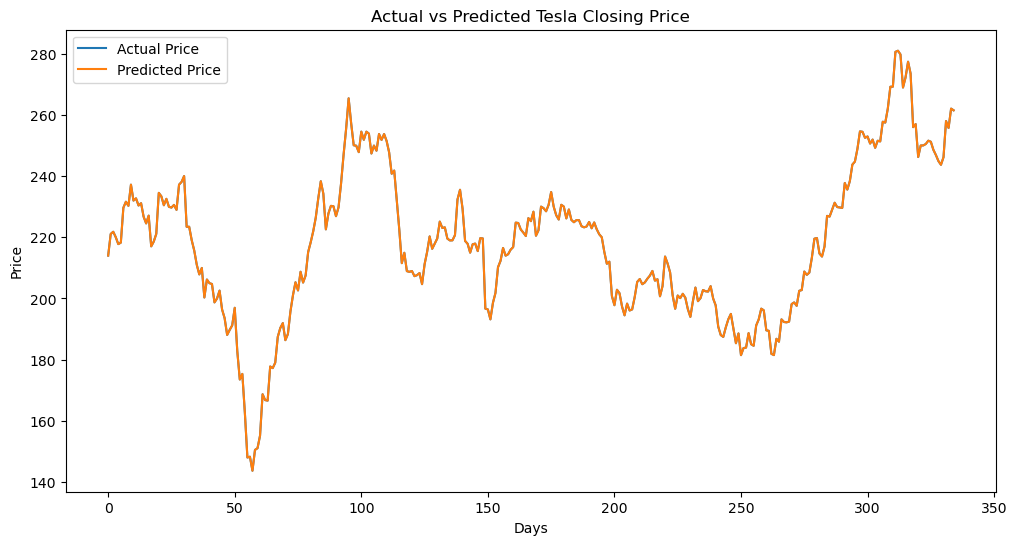

In [15]:
predictions = best_model.predict(X_test_scaled)

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual Price")

plt.plot(predictions, label="Predicted Price")

plt.title("Actual vs Predicted Tesla Closing Price")

plt.xlabel("Days")

plt.ylabel("Price")

plt.legend()

plt.show()


## STEP 15: SAVE MODEL

In [16]:
joblib.dump(best_model, "tesla_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("\nModel saved successfully!")


Model saved successfully!


## STEP 16: NEXT DAY PREDICTION

In [17]:
latest_data = X.iloc[-1].values.reshape(1, -1)

latest_scaled = scaler.transform(latest_data)

next_day_prediction = best_model.predict(latest_scaled)

print("\nPredicted Next Day Closing Price:",
      next_day_prediction[0])


Predicted Next Day Closing Price: 261.49999999999994


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## STEP 17: NEXT 7 DAYS FORECAST

In [18]:
future_predictions = []

temp_df = X.iloc[-1:].copy()

for i in range(7):

    temp_scaled = scaler.transform(temp_df)

    pred = best_model.predict(temp_scaled)[0]

    future_predictions.append(pred)

    # update lag values
    temp_df['Lag_3'] = temp_df['Lag_2']
    temp_df['Lag_2'] = temp_df['Lag_1']
    temp_df['Lag_1'] = pred

    # update moving averages
    temp_df['MA5'] = (temp_df['MA5'] * 4 + pred) / 5
    temp_df['MA10'] = (temp_df['MA10'] * 9 + pred) / 10
    temp_df['MA20'] = (temp_df['MA20'] * 19 + pred) / 20

    # update price change
    temp_df['Price_Change'] = pred - temp_df['Open']

print("\nNEXT 7 DAYS FORECAST:")

for i, value in enumerate(future_predictions, 1):

    print(f"Day {i}: {value}")


NEXT 7 DAYS FORECAST:
Day 1: 261.49999999999994
Day 2: 261.4999999999999
Day 3: 261.49999999999983
Day 4: 261.4999999999998
Day 5: 261.4999999999997
Day 6: 261.49999999999966
Day 7: 261.4999999999996
